<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 700; line-height: 1.2;">
        Visualización de Datos
      </h1>
      <p style="margin: 6px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Programación para Ciencia de Datos
      </p>
    </td>
    <td style="vertical-align: middle; text-align: right; border: none; padding: 15px 20px; min-width: 240px; font-family: system-ui, -apple-system, sans-serif;">
      <div style="font-size: 0.9em; color: #334155; line-height: 1.5;">
        <strong style="color: #1e3a8a; font-size: 1em;">Especialización en Ciencia de Datos</strong><br>
        <span style="color: #475569; font-weight: 600;">USTA Tunja</span><br><br>
        <b>Santiago A. Zúñiga M.</b><br>
        ✉️ <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
      </div>
    </td>
  </tr>
</table>

---
## Visualización de Datos 

Por defecto, **Pandas** viene con la librería `matplotlib` incorporada, lo que nos permite hacer gráficos rápidos y sencillos. Sin embargo, para crear visualizaciones mucho más atractivas e informativas desde el punto de vista estadístico, utilizamos **Seaborn**.

> Seaborn es una librería de visualización de datos en Python basada en `matplotlib`. Proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos.

Comencemos importando nuestras herramientas y cargando el misterioso dataset de cuartetos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Evitar advertencias visuales de Seaborn
import warnings
warnings.filterwarnings('ignore')

quartets = pd.read_csv('data/quartets.csv', index_col=0)
quartets.head()

,x,y,quartet
1,10,8.04,I
2,8,6.95,I
3,13,7.58,I
4,9,8.81,I
5,11,8.33,I


---
### 1. Diagramas de Caja (BoxPlot) 📦

Los diagramas de caja proporcionan un resumen de la distribución, incluyendo la mediana, los cuartiles y los posibles valores atípicos (outliers). 

- La **caja** representa el Rango Intercuartílico (IQR = Q3 - Q1).
- Los **bigotes** se extienden hasta los valores mínimos y máximos dentro de un rango determinado. Por defecto, se extienden no más de `1.5 * IQR` desde los bordes de la caja.
- Los **valores atípicos** se trazan como puntos separados.



#### 1.1 Boxplots con Pandas
Pandas nos permite generar boxplots agrupados de forma muy directa.

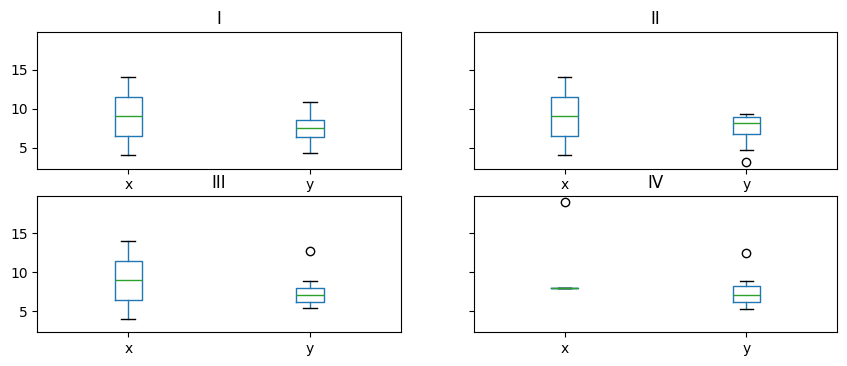

In [2]:
quartets.groupby('quartet').boxplot(grid=False, figsize=(10, 4));

#### 1.2 Paletas de Colores de Seaborn

📚 **Documentación:** [Paletas de Seaborn](https://seaborn.pydata.org/tutorial/color_palettes.html)

Antes de usar Seaborn, configuremos una paleta de colores para mejorar la estética.

In [3]:
sns.color_palette('pastel')

[(0.6313725490196078, 0.788235294117647, 0.9568627450980393),
 (1.0, 0.7058823529411765, 0.5098039215686274),
 (0.5529411764705883, 0.8980392156862745, 0.6313725490196078),
 (1.0, 0.6235294117647059, 0.6078431372549019),
 (0.8156862745098039, 0.7333333333333333, 1.0),
 (0.8705882352941177, 0.7333333333333333, 0.6078431372549019),
 (0.9803921568627451, 0.6901960784313725, 0.8941176470588236),
 (0.8117647058823529, 0.8117647058823529, 0.8117647058823529),
 (1.0, 0.996078431372549, 0.6392156862745098),
 (0.7254901960784313, 0.9490196078431372, 0.9411764705882353)]

In [4]:
palette = 'pastel'

#### 1.3 Boxplots con Seaborn
Podemos crear diagramas de caja similares usando Matplotlib y Seaborn en conjunto.

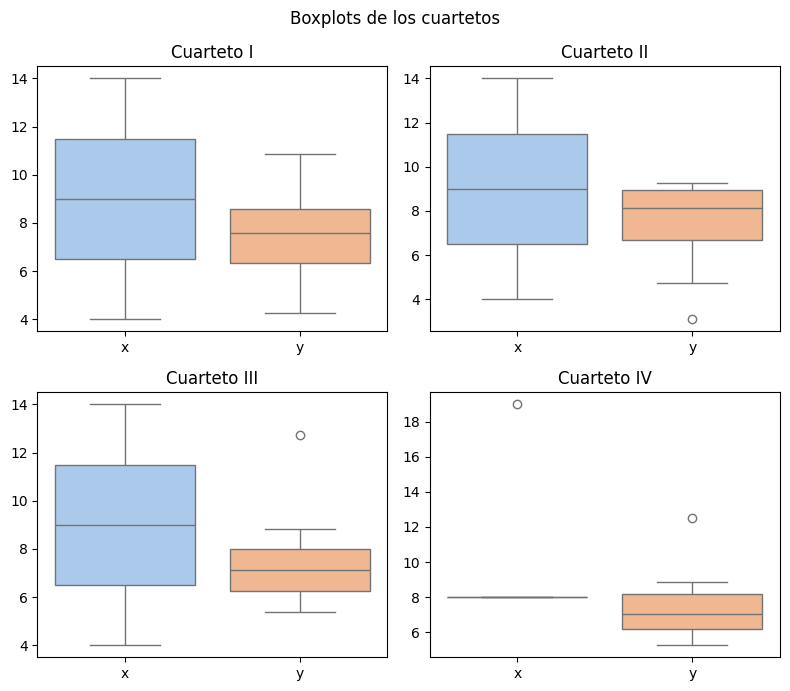

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(8, 7))
axes = axes.flatten().tolist()

for quartet, g in quartets.groupby('quartet'):
    ax = axes.pop(0)
    sns.boxplot(data=g, ax=ax, palette=palette)
    ax.set_title(f'Cuarteto {quartet}')
    
plt.suptitle("Boxplots de los cuartetos");
plt.tight_layout()

#### 1.4 Unificando características con `pd.melt()`

📚 **Documentación:** 
- [seaborn.boxplot()](https://seaborn.pydata.org/generated/seaborn.boxplot.html)
- [pandas.melt()](https://pandas.pydata.org/docs/reference/api/pandas.melt.html)

Podemos derretir (melt) el DataFrame para comparar las características `x` e `y` en el mismo gráfico.

,quartet,variable,value
0,I,x,10.0
1,I,x,8.0
2,I,x,13.0
3,I,x,9.0
4,I,x,11.0


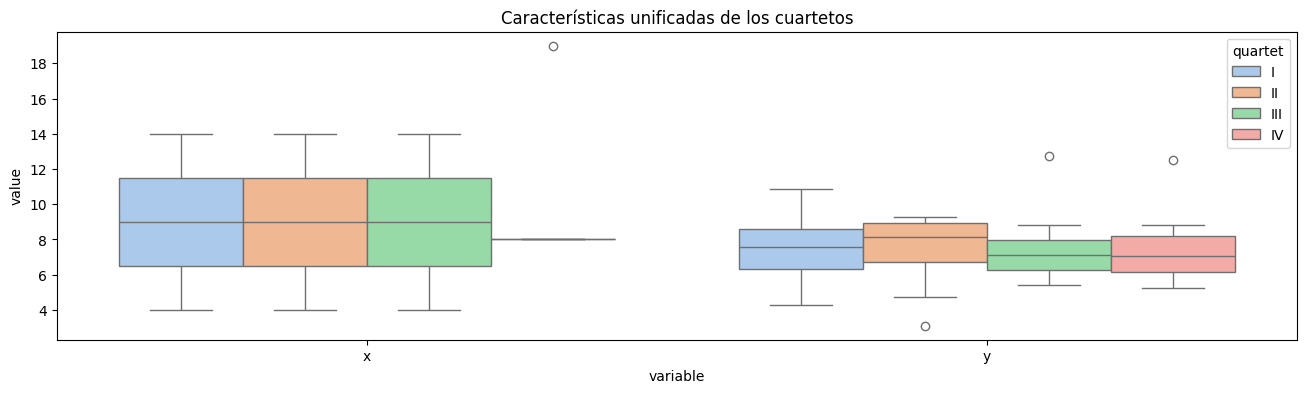

In [6]:
melted = pd.melt(quartets, id_vars='quartet', var_name='variable', value_name='value')
display(melted.head())

fig, ax = plt.subplots(1, 1, figsize=(16, 4))
sns.boxplot(x='variable', y='value', hue='quartet', data=melted, ax=ax, palette=palette)
ax.set_title("Características unificadas de los cuartetos");

**⚠️ El problema con el gráfico anterior** es que estamos forzando características diferentes (como `x` e `y`) a compartir el mismo eje Y. 

Por lo tanto, otra forma de lograr el objetivo es iterar por columna:

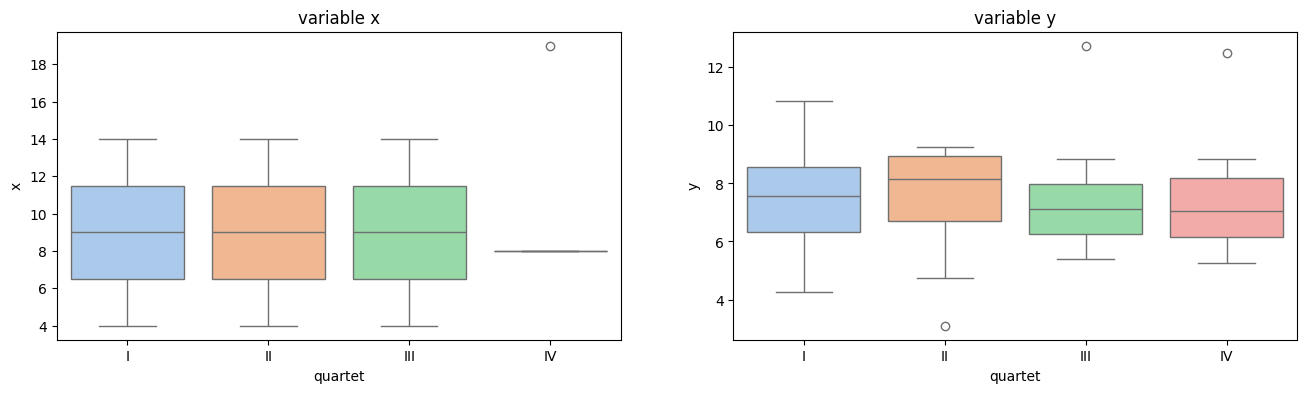

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for i, col in enumerate(['x', 'y']):
    sns.boxplot(x='quartet', y=col, data=quartets, ax=axes[i], palette=palette)
    axes[i].set_title(f'variable {col}')

---
##### 🛠️ Práctica 1: Boxplots Modificados
El rango por defecto de los bigotes (whiskers) en un boxplot es `1.5 * IQR`. Tu tarea es graficar los diagramas de caja de los 4 cuartetos con Seaborn (usando la variable `y`), pero esta vez extiende los bigotes **hasta el máximo y mínimo absolutos** de los datos para que no queden valores atípicos (puntos sueltos).
*(Pista: revisa el parámetro `whis`)*

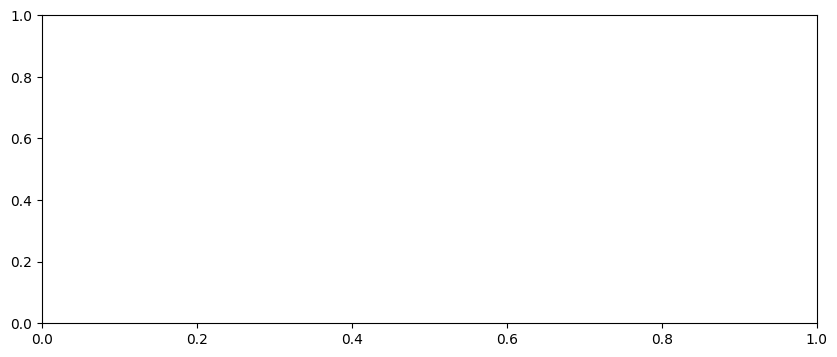

In [8]:
# Escribe tu código aquí
fig, ax = plt.subplots(figsize=(10, 4))
# sns.boxplot(x=..., y=..., data=..., whis=...)

<details>
<summary><b>💡 Haz clic aquí para ver la solución</b></summary>

```python
sns.boxplot(x='quartet', y='y', data=quartets, ax=ax, whis=float('inf'), palette=palette)
```
</details>


---
### 2. Histogramas 📊

Los histogramas proporcionan una representación visual de la distribución de una variable continua. Los datos se dividen en contenedores (bins), y la altura de cada barra representa la frecuencia o recuento de observaciones dentro de ese contenedor.



#### 2.1 Histogramas en Pandas
Pandas nos permite graficar fácilmente el histograma de las características de cada cuarteto en una sola línea de código.

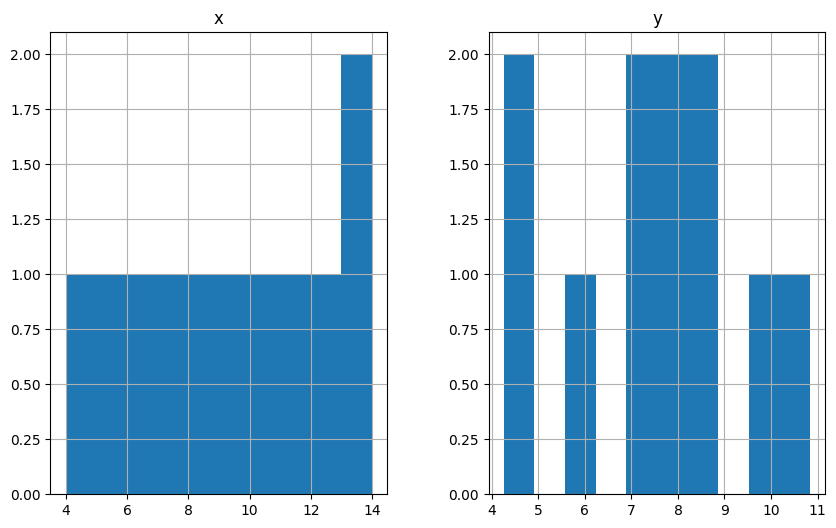

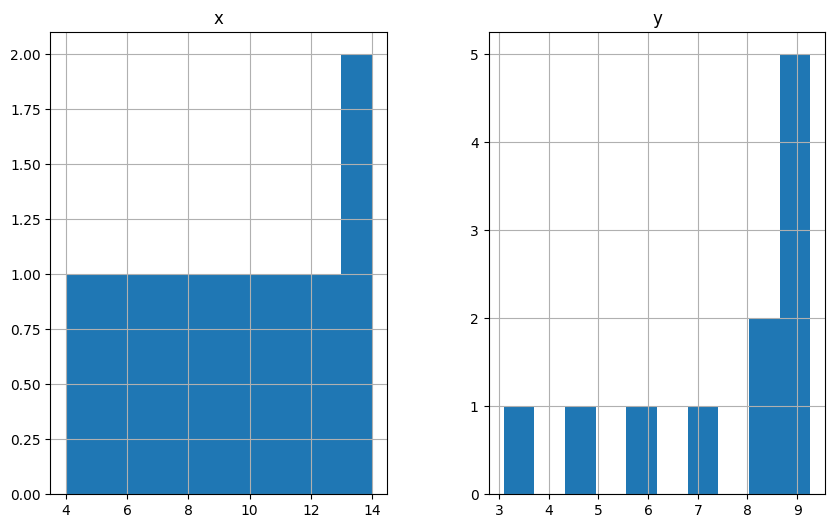

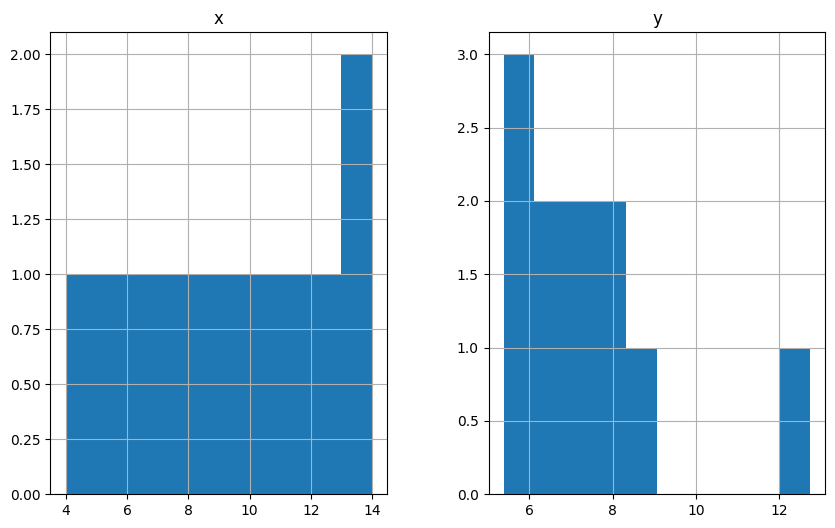

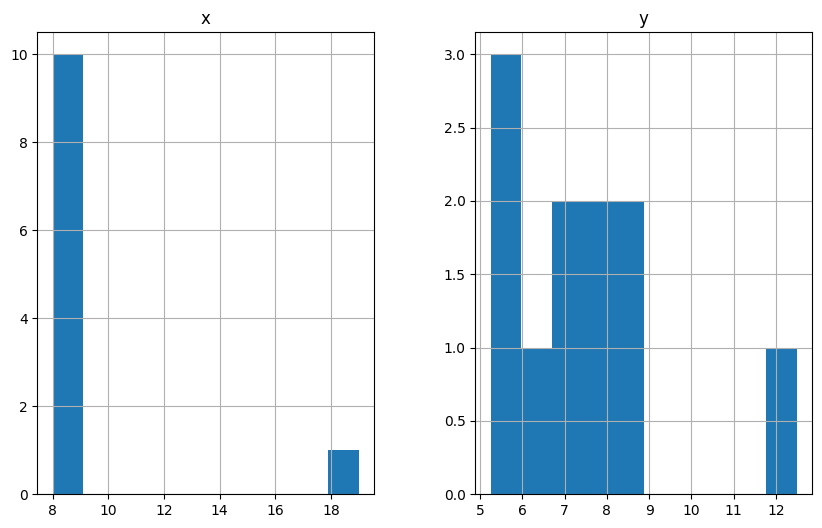

In [9]:
quartets.groupby('quartet').hist(figsize=(10, 6));

Los histogramas nos permiten empezar a ver algunas diferencias entre los grupos.

#### 2.2 Histogramas en Seaborn
📚 **Documentación:** [seaborn.histplot()](https://seaborn.pydata.org/generated/seaborn.histplot.html)

Podemos hacer lo mismo con Seaborn agrupando y dibujando la curva KDE (estimación de densidad de kernel):

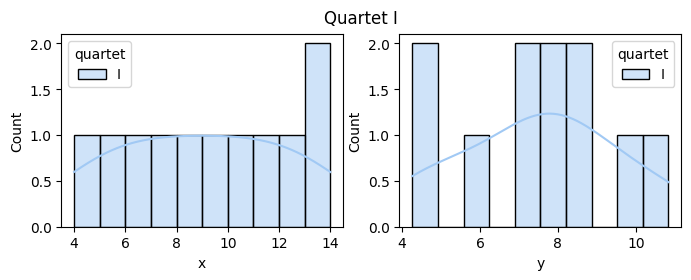

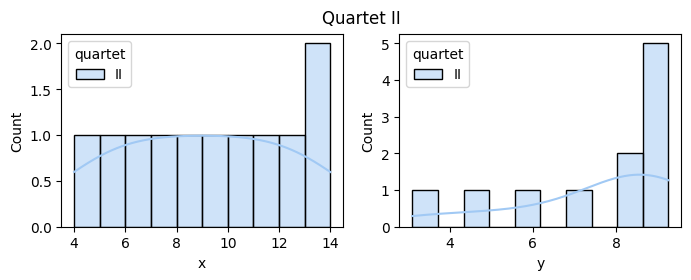

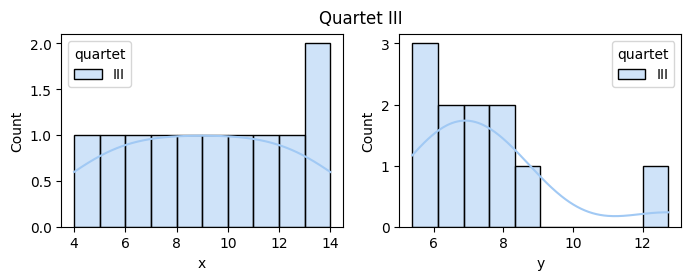

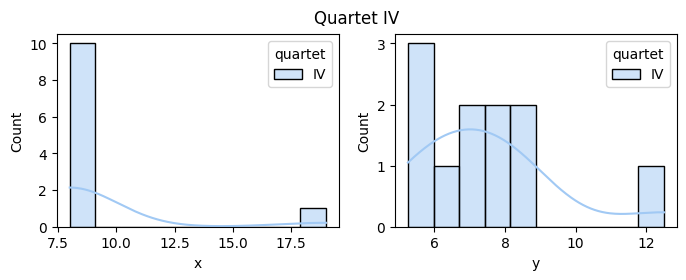

In [10]:
for quartet, g in quartets.groupby('quartet'):
    fig, axes = plt.subplots(1 , 2, figsize=(8, 2.5))
    sns.histplot(data=g, x="x", hue='quartet', ax=axes[0], palette=palette, bins=10, kde=True)
    sns.histplot(data=g, x="y", hue='quartet', ax=axes[1], palette=palette, bins=10, kde=True)
    plt.suptitle(f'Quartet {quartet}')

#### 2.3 Histogramas Superpuestos
Podemos graficar todas las características `x` e `y` de los cuartetos en dos gráficos diferentes, superponiéndolos usando el parámetro `element='step'` y aplicando transparencia (`alpha`).

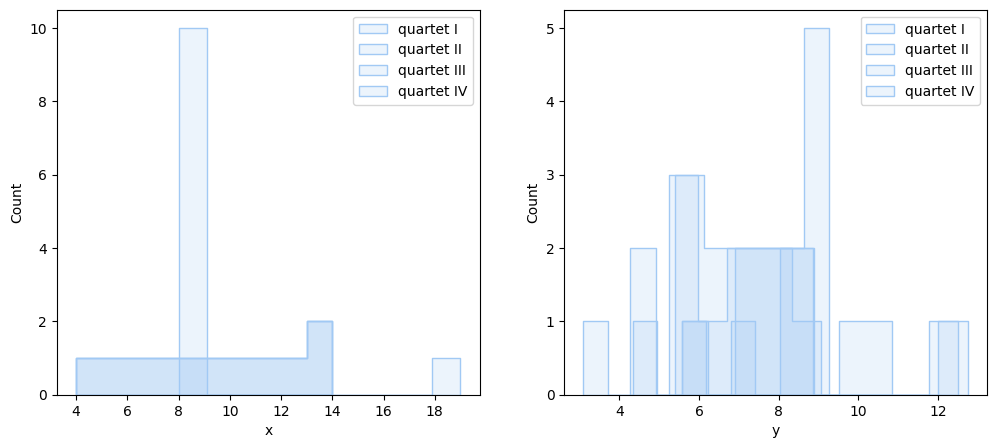

In [11]:
# El parámetro 'element' define la representación visual. Puede ser 'bars', 'step' o 'poly'.
element = 'step'
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
legends = []

for quartet, g in quartets.groupby('quartet'):
    legends.append(f'quartet {quartet}')
    sns.histplot(data=g, x="x", hue='quartet', ax=axes[0], palette=palette, bins=10, kde=False, alpha=.2, element=element)
    sns.histplot(data=g, x="y", hue='quartet', ax=axes[1], palette=palette, bins=10, kde=False, alpha=.2, element=element)

axes[0].legend(legends)
axes[1].legend(legends);

---
##### 🛠️ Práctica 2: Jugando con Bins y KDE
Grafica un histograma con Seaborn para la variable `y` de todo el dataset completo (sin separar por cuartetos). Configura `20` contenedores (bins) y enciende la curva KDE. 
Observa cómo cambia la resolución de la forma de campana.

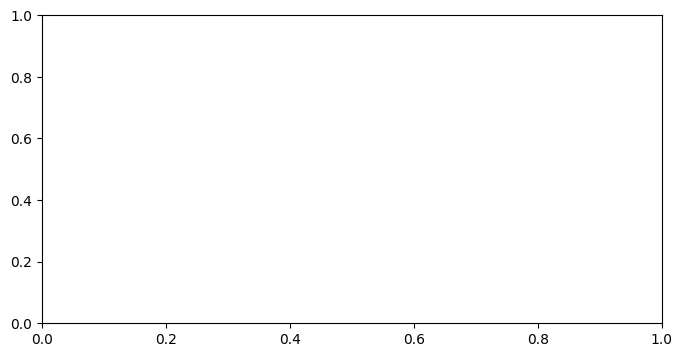

In [12]:
# Escribe tu código aquí
fig, ax = plt.subplots(figsize=(8, 4))
# sns.histplot(data=..., x=..., bins=..., kde=...)


<details>
<summary><b>💡 Haz clic aquí para ver la solución</b></summary>

```python
sns.histplot(data=quartets, x='y', bins=20, kde=True, ax=ax, color='teal')
```
</details>


---
### 3. FacetGrid ✨

Esta es una herramienta poderosa que se puede usar en combinación con los métodos de graficación de Seaborn o Matplotlib para crear múltiples subgráficos basados en una relación condicional.

📚 **Documentación:** [seaborn.FacetGrid()](https://seaborn.pydata.org/generated/seaborn.FacetGrid.html): Cuadrícula multiplano para graficar relaciones condicionales.



#### 3.1 Cuadrícula de Histogramas

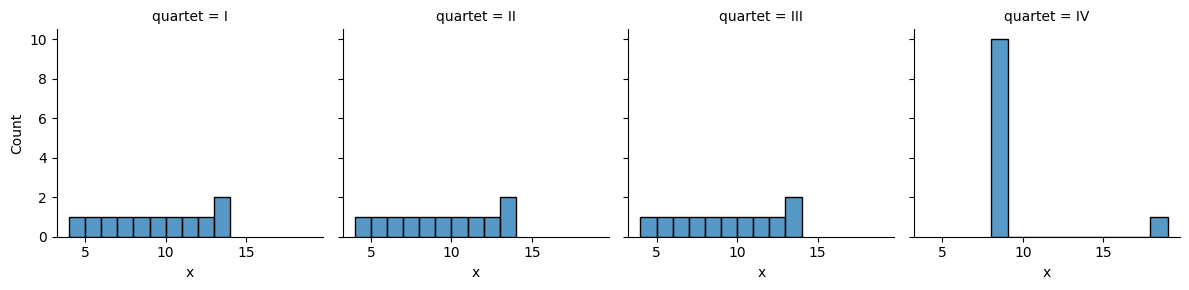

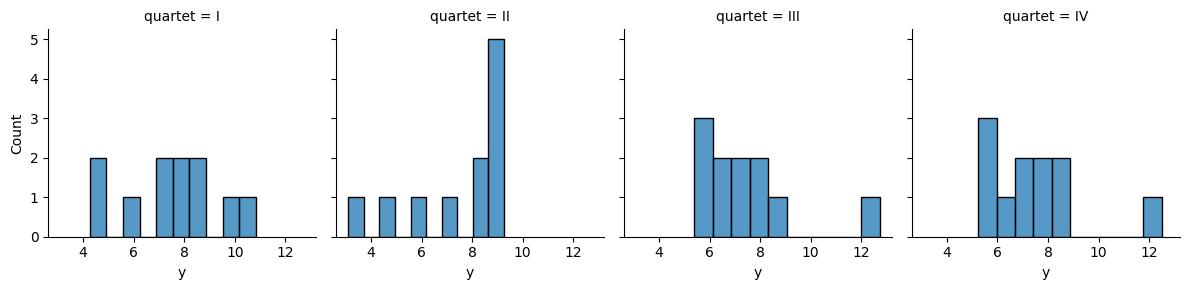

In [13]:
for feature in ['x', 'y']:
    # Creamos la grilla con la condición quartet
    g = sns.FacetGrid(quartets, col="quartet", palette=palette, col_wrap=4)
    # Para cada condición creamos un subplot (histplot) para la columna "feature"
    g.map(sns.histplot, feature, bins=10)
    # col_wrap define el número de columnas. Cambia el valor a 3 o 2 para entenderlo.

#### 3.2 FacetGrid Maestro con pd.melt()
Podemos crear un `FacetGrid` para **todo** de una sola vez. Para ello, convertimos el dataframe para acceder a los valores basados en condiciones tanto de filas como de columnas.

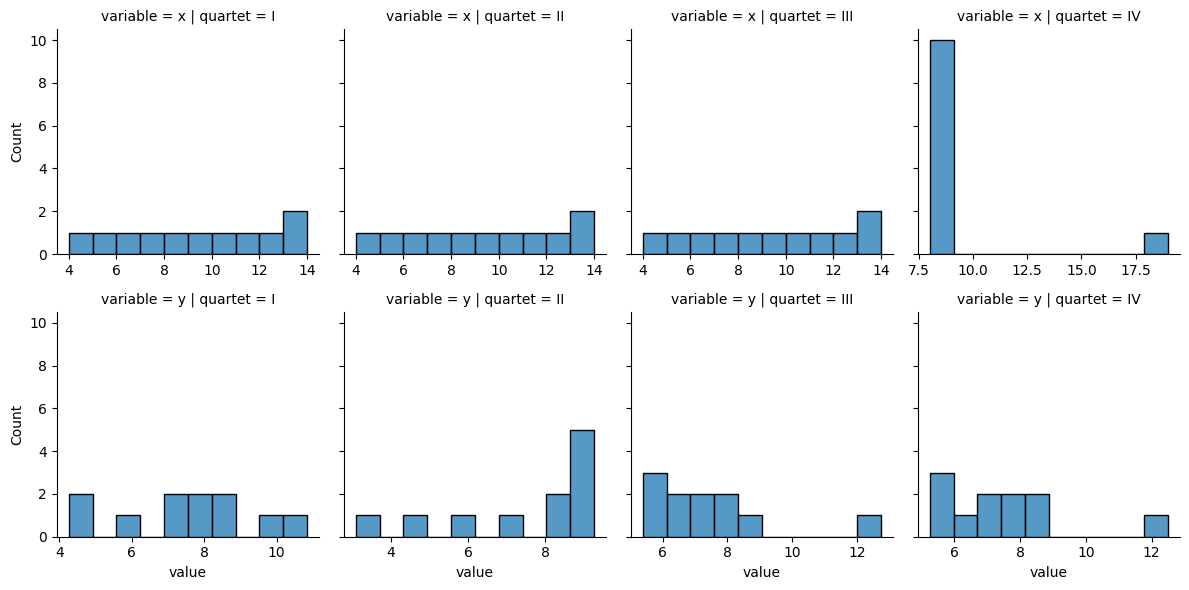

In [14]:
melted = pd.melt(quartets, id_vars='quartet', var_name='variable', value_name='value')

# Creamos la grilla con los cuartetos como columnas y las variables como filas
g = sns.FacetGrid(melted, row="variable", col='quartet', palette=palette, sharex=False)
g.map(sns.histplot, 'value', bins=10);

# Nota: Necesitamos establecer sharex=False para evitar distorsionar las formas entre las filas.

---
##### 🛠️ Práctica 3: FacetGrid de Cajas
El FacetGrid no es exclusivo de los histogramas. Utiliza el dataframe `melted` y crea un `FacetGrid` separando por columnas los `quartet`, pero mapea la función `sns.boxplot` para visualizar los rangos de la columna `value`.

In [15]:
# Escribe tu código aquí
# g = sns.FacetGrid(melted, col=...)
# g.map(sns.boxplot, ...)

<details>
<summary><b>💡 Haz clic aquí para ver la solución</b></summary>

```python
g = sns.FacetGrid(melted, col='quartet', palette=palette, height=4)
g.map(sns.boxplot, 'value')
```
</details>


---
### 4. Diagramas de Dispersión (Scatter plots) 🌌

Sabiendo que tenemos las características `x` e `y`, podemos pensar en usar otro tipo de gráfico útil. ¿Por qué no un scatter plot?



#### 4.1 Scatter Plots con Pandas

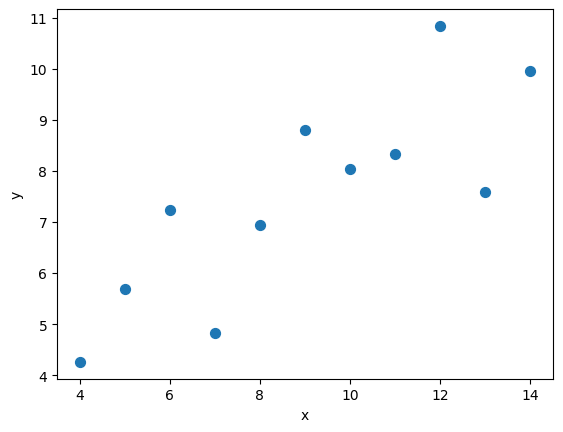

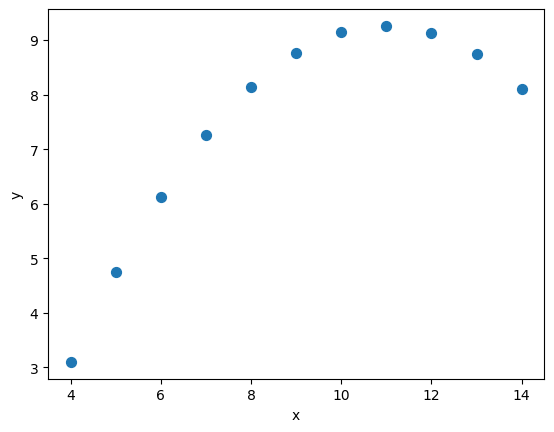

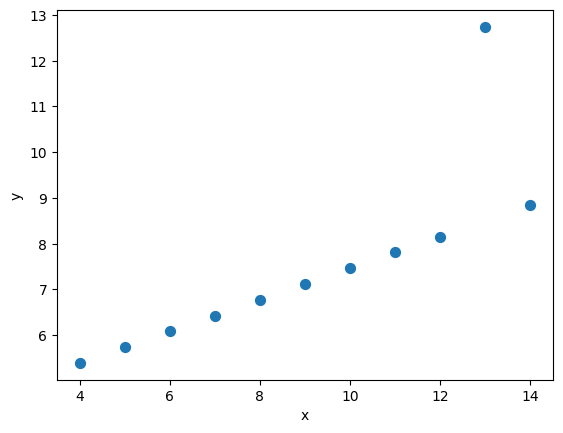

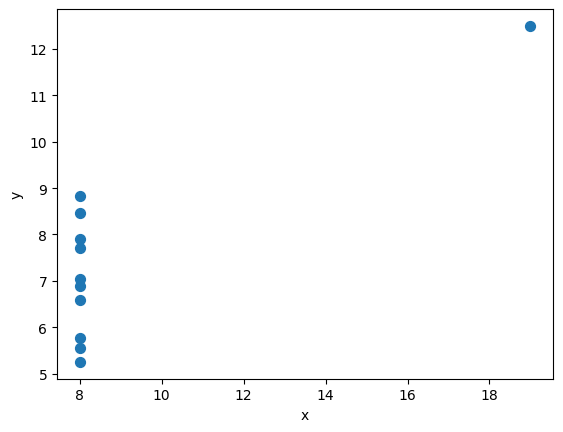

In [16]:
quartets.groupby('quartet').plot.scatter(x='x', y='y', s=50);

#### 4.2 Scatter Plots con Seaborn
Podemos combinar matplotlib con seaborn para mejorar la estética.

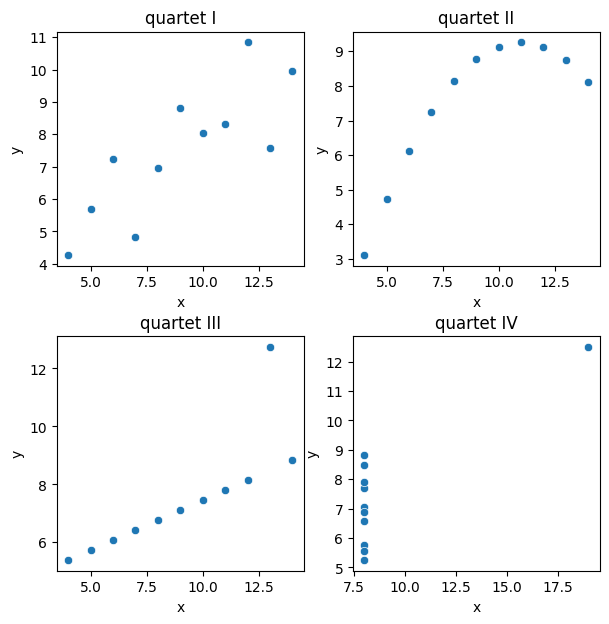

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(7, 7))
axes = axes.flatten().tolist()

for quartet, g in quartets.groupby('quartet'):
    ax = axes.pop(0)
    sns.scatterplot(data=g, x='x', y='y', ax=ax)
    ax.set_title(f'quartet {quartet}')
    
plt.subplots_adjust(hspace=0.3);

#### 4.3 Scatter Plots con FacetGrid
FacetGrid es excelente para evitar escribir demasiadas líneas de código de matplotlib. En este caso forzaremos a la grilla a compartir los dominios X e Y para simplificar la comparación.

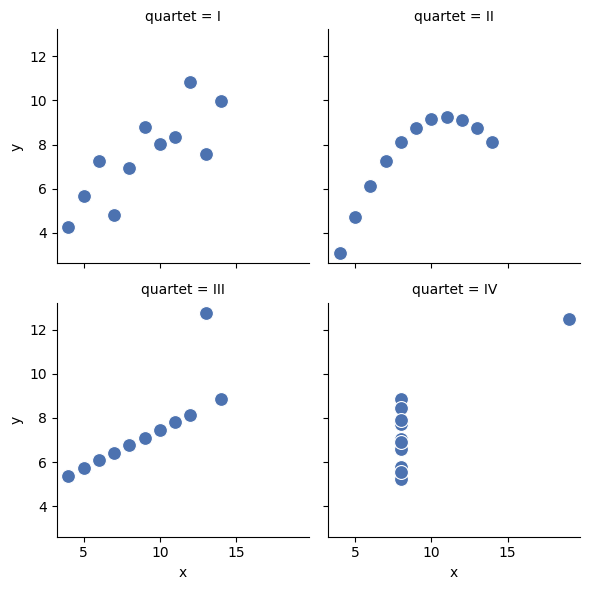

In [18]:
g = sns.FacetGrid(quartets, col='quartet', palette=palette, col_wrap=2, sharex=True, sharey=True, height=3)
g.map(sns.scatterplot, 'x', 'y', s=100, color="#4c72b0");

#### 🤯 ¡MISTERIO RESUELTO!

¿Recuerdas que la estadística descriptiva decía que **estos 4 datasets eran idénticos**?
- **Cuarteto I:** Relación lineal simple.
- **Cuarteto II:** Curva parabólica perfecta.
- **Cuarteto III:** Línea recta perfecta con **un gran outlier**.
- **Cuarteto IV:** Constante con un outlier masivo.

¡Esta es la demostración definitiva de por qué jamás se debe saltar la visualización!

---
### 5. Gráficos de Líneas (Line plots) 📈

Podríamos usar un lineplot, pero para hacerlo necesitamos saber que los puntos deben estar ordenados en el eje X.



#### 5.1 Gráficos de Líneas con Pandas

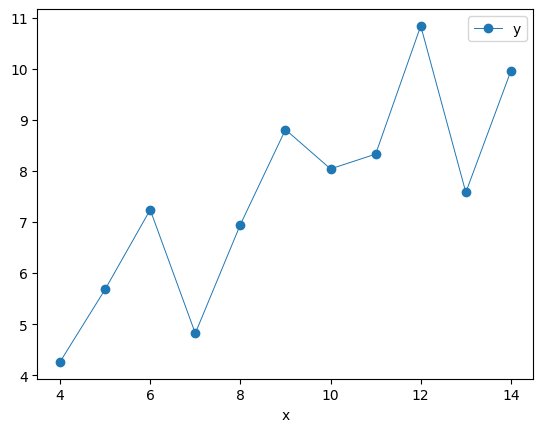

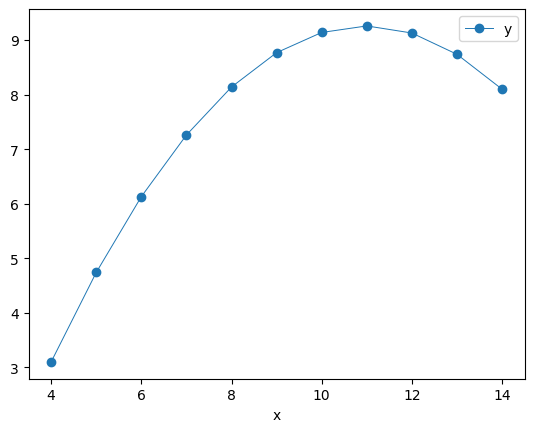

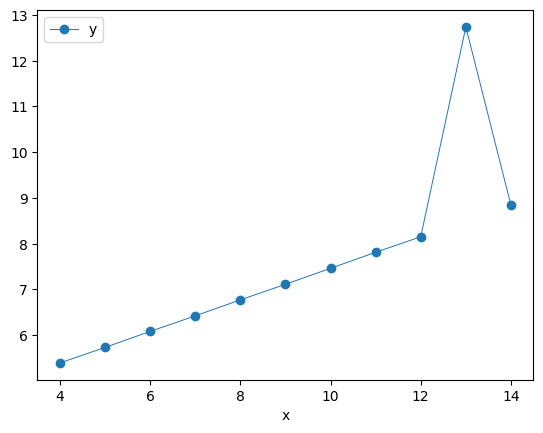

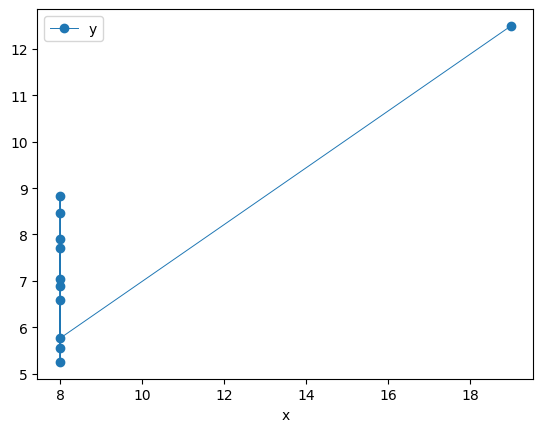

In [19]:
quartets.sort_values(by='x').groupby('quartet').plot(x='x', y='y', marker='o', lw=.7);

#### 5.2 Todos en uno (Pandas/Matplotlib)
También podemos usar matplotlib para graficar todos los grupos en el mismo gráfico.

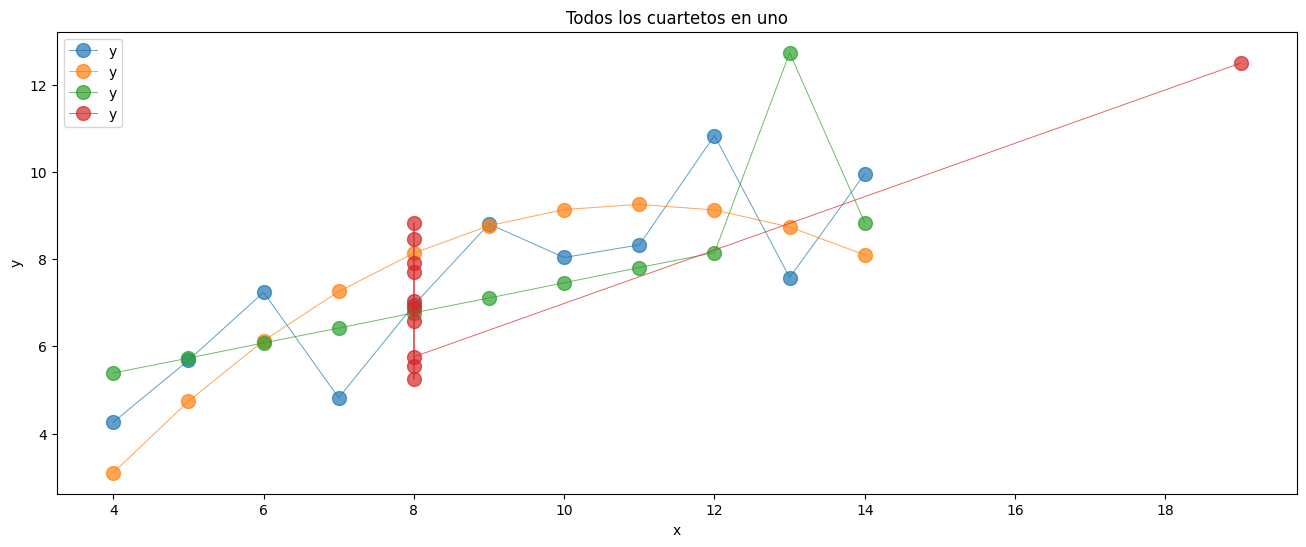

In [20]:
# creamos una figura de 1 x 1
fig, ax = plt.subplots(1, 1, figsize=(16, 6))

# graficamos los 4 cuartetos en el mismo ax
quartets.sort_values(by='x').groupby('quartet').plot(x='x', y='y', marker='o', ms=10, lw=.7, alpha=.7, ax=ax)
plt.ylabel('y')
plt.title('Todos los cuartetos en uno');

#### 5.3 Gráficos de Líneas con Seaborn
📚 **Documentación:** [Seaborn.lineplot()](https://seaborn.pydata.org/generated/seaborn.lineplot.html)

Seaborn simplifica la creación del mismo gráfico.

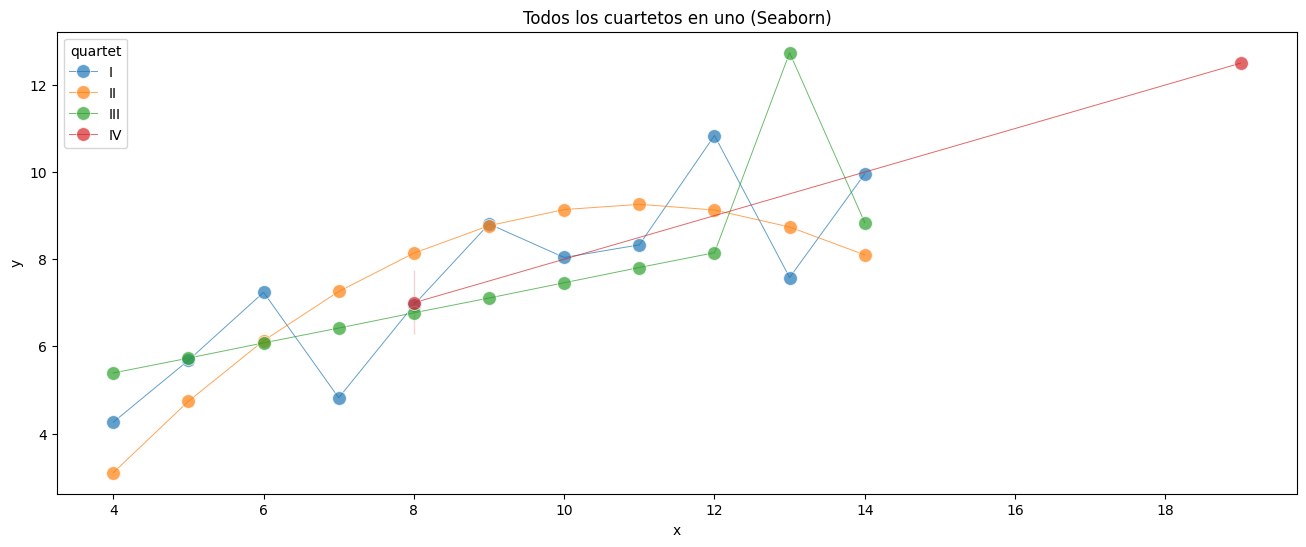

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(16, 6))
sns.lineplot(data=quartets, x='x', y='y', hue='quartet', marker='o', ms=10, lw=.7, alpha=.7, ax=ax)
plt.title('Todos los cuartetos en uno (Seaborn)');

Y podemos graficar todos los cuartetos juntos removiendo el condicional `hue` para Seaborn, notando la diferencia de cómo calculan los intervalos.

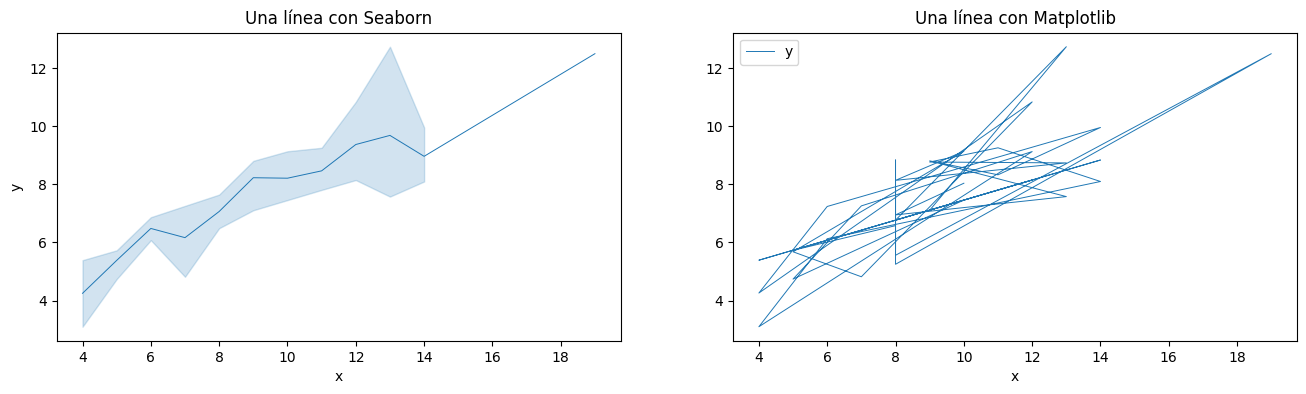

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.lineplot(data=quartets, x='x', y='y', lw=.7, ax=axes[0])
axes[0].set_title('Una línea con Seaborn')

quartets.plot(x='x', y='y', lw=.7, ax=axes[1])
axes[1].set_title('Una línea con Matplotlib');

---
##### 🛠️ Práctica 4: Imitando comportamientos
Seaborn está construido sobre Matplotlib, así que modificando los parámetros de la función debería permitirte llegar a la misma gráfica plana.

Modifica los parámetros de la función `sns.lineplot()` para que los dos gráficos se vean visualmente similares (apaga el intervalo de confianza y el estimador estadístico).
*(Pista: revisa en internet el parámetro `errorbar` o `ci`)*

<Axes: xlabel='x', ylabel='y'>

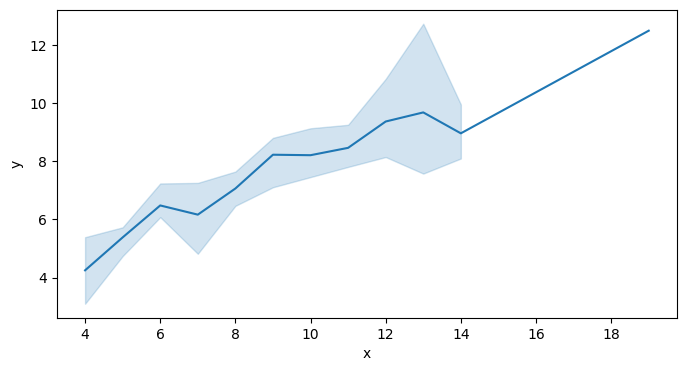

In [23]:
# Escribe tu código aquí
fig, ax = plt.subplots(1, 1, figsize=(8,4))
# Modifica esta línea:
sns.lineplot(data=quartets, x='x', y='y', ax=ax)


<details>
<summary><b>💡 Haz clic aquí para ver la solución</b></summary>

```python
sns.lineplot(data=quartets, x='x', y='y', ax=ax, errorbar=None, estimator=None)
```
</details>
